In [67]:
import json
import random
import csv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [68]:
all_data = json.load(open('./raw_data.json', 'r'))

In [69]:
len(all_data)

820

In [70]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    if entry['task'] == 'classify' and entry['ab'] == 'A':
        data.extend(dict(item, worker=entry['workerId']) for item in entry['items'])

In [71]:
EMOJI = sorted({choice['code'] for row in data for choice in row['choices']})
faces = sorted(set(row['file'] for row in data))

In [72]:
len(data), len(EMOJI), len(faces)

(3600, 68, 20)

0.19666666666666666


(array([3.354e+03, 1.470e+02, 5.500e+01, 2.800e+01, 1.000e+01, 1.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00]),
 array([ 1.,  5.,  9., 13., 17., 21., 25., 29., 33., 37., 41.]),
 <BarContainer object of 10 artists>)

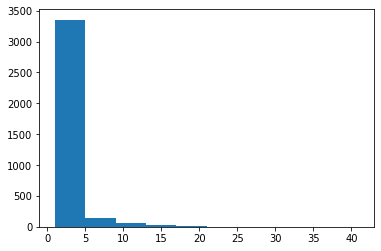

In [73]:
print(np.mean([row['sample']>1 for row in data]))
plt.hist([row['sample'] for row in data])

In [40]:
def get_data(data, face):
    return [
        {
            "choices": [EMOJI.index(choice['code']) for choice in row['choices']],
            "selected": EMOJI.index(row['choices'][row['selected']]['code'])
        }
        for row in data if row['file'] == face
    ]

In [41]:
def loss(DATA, x):
        denom_mat = np.zeros((len(DATA),x.shape[0]))
        num_mat = np.zeros((len(DATA),x.shape[0]))
        for i in range(len(DATA)):
            denom_mat[i, DATA[i]['choices']] = 1.0
            num_mat[i, DATA[i]['selected']] = 1.0
        exp_x = tf.exp(x)
        loss = -tf.reduce_sum(
            tf.math.log(
                tf.linalg.matmul(num_mat, exp_x) / 
                tf.linalg.matmul(denom_mat, exp_x)))
        return loss

In [42]:
def fit_model(data):
    RESULT = np.zeros((len(faces), len(EMOJI)))
    for f in range(len(faces)):
        face = faces[f]
        x = tf.Variable(np.zeros((len(EMOJI),1)))
        DATA= get_data(data, face)
        opt = tf.keras.optimizers.Adam(learning_rate = 0.1, epsilon=0.01)
        with tf.GradientTape(persistent=True) as tape:
            L = lambda: loss(DATA,x)
        print(f"{face=}: ", end="")
        for epoch in range(10):
            print(f".", end="")
            x_old = np.exp(x.numpy())
            for iter in range(100):
                opt.minimize(L, [x], tape=tape)
                x.assign(x - tf.math.reduce_max(x))
            dist = np.max(np.abs(x_old - np.exp(x.numpy())))/np.sum(np.exp(x_old))
            if dist < 0.0001:
                break
        print()
        x_opt = np.round(np.exp(x.numpy())/np.sum(np.exp(x.numpy())), 4)
        RESULT[f,:] = np.squeeze(x_opt)
    return RESULT


In [43]:
RESULT = fit_model(data)
with open('gen/resultA.json', 'w') as out:
    json.dump({
        faces[i] : {
            "x_opt" : {"%0x" % EMOJI[j] : RESULT[i][j] for j in range(len(EMOJI))},
        }
        for i in range(len(faces))
    }, out, indent=2)

face='img_align_celeba/000838.jpg': ...
face='img_align_celeba/012499.jpg': ...
face='img_align_celeba/024857.jpg': ..
face='img_align_celeba/029376.jpg': ...
face='img_align_celeba/036568.jpg': ..
face='img_align_celeba/090689.jpg': ..
face='img_align_celeba/092099.jpg': ..
face='img_align_celeba/093560.jpg': ..
face='img_align_celeba/106786.jpg': ..
face='img_align_celeba/117396.jpg': ..
face='img_align_celeba/128198.jpg': ..
face='img_align_celeba/153630.jpg': ..
face='img_align_celeba/167840.jpg': ...
face='img_align_celeba/168485.jpg': ...
face='img_align_celeba/173110.jpg': ...
face='img_align_celeba/181029.jpg': ..
face='img_align_celeba/195696.jpg': ...
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ...
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': ..
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': ..


In [44]:
len(set([np.argmax(RESULT[i]) for i in range(len(faces))]))

11

# Bayesian decoding

In [45]:
workers = np.random.permutation(sorted(set(row['worker'] for row in data)))
selected = { workers[i] : i < len(workers)//2 for i in range(len(workers)) } 

In [46]:
data1 = [row for row in data if selected[row['worker']]]
data2 = [row for row in data if not selected[row['worker']]]
Result1 = fit_model(data1)
Result2 = fit_model(data2)
encoded = [ np.argmax(x_opt) for x_opt in Result1]

face='img_align_celeba/000838.jpg': ...
face='img_align_celeba/012499.jpg': ...
face='img_align_celeba/024857.jpg': ..
face='img_align_celeba/029376.jpg': ...
face='img_align_celeba/036568.jpg': ..
face='img_align_celeba/090689.jpg': ..
face='img_align_celeba/092099.jpg': ..
face='img_align_celeba/093560.jpg': ..
face='img_align_celeba/106786.jpg': ..
face='img_align_celeba/117396.jpg': ..
face='img_align_celeba/128198.jpg': ..
face='img_align_celeba/153630.jpg': ..
face='img_align_celeba/167840.jpg': ...
face='img_align_celeba/168485.jpg': ..
face='img_align_celeba/173110.jpg': ...
face='img_align_celeba/181029.jpg': ..
face='img_align_celeba/195696.jpg': ..
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ...
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': ..
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': ..
face='img_align_celeba/000838.jpg': ...
face='img_align_celeba/012499.jpg': ...
face='img_align_celeba/024857.jpg': ...
face='img_align_celeba/029376.jpg': ...
face='img_align_cel

In [59]:
total = 0
successes = 0
y = 5
for i in range(len(faces)):
    e_star = np.argmax(Result1[i])
    ti, si = 0,0
    for j in range(20):
        others = list(range(0,i)) + list(range(i+1,len(faces)))
        decoys = np.random.choice(others, y, replace=False)
        success = Result1[i][e_star] > np.max(Result2[decoys, e_star])
        si += success
        ti += 1
    print(f"{i+1:2d} {faces[i]:41s}: {100 * si/ti:6.2f}")
    total += ti
    successes += si

 1 img_align_celeba/000838.jpg              : 100.00
 2 img_align_celeba/012499.jpg              : 100.00
 3 img_align_celeba/024857.jpg              : 100.00
 4 img_align_celeba/029376.jpg              : 100.00
 5 img_align_celeba/036568.jpg              :  30.00
 6 img_align_celeba/090689.jpg              :  50.00
 7 img_align_celeba/092099.jpg              : 100.00
 8 img_align_celeba/093560.jpg              : 100.00
 9 img_align_celeba/106786.jpg              :  40.00
10 img_align_celeba/117396.jpg              :  25.00
11 img_align_celeba/128198.jpg              : 100.00
12 img_align_celeba/153630.jpg              :  75.00
13 img_align_celeba/167840.jpg              : 100.00
14 img_align_celeba/168485.jpg              : 100.00
15 img_align_celeba/173110.jpg              : 100.00
16 img_align_celeba/181029.jpg              : 100.00
17 img_align_celeba/195696.jpg              : 100.00
18 lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg :  70.00
19 lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg : 

In [48]:
print(f"{successes}/{total} = {100*successes/total:.2f}")
print(f"M={y/(total/successes-1):.2f}")

311/400 = 77.75
M=17.47


In [49]:
len(set([np.argmax(Result1[i]) for i in range(len(faces))]))

13

In [64]:
total = 0
successes = 0
y = 5
M = 9
for i in range(2000):
    collisions = 0
    for j in range(y):
        collisions += np.random.randint(M)==0
    total += 1
    successes += 1/(1+collisions)

In [65]:
print(f"{successes:.2f}/{total} = {100*successes/total:.2f}")
print(f"M={M}")

1507.92/2000 = 75.40
M=9
